# TD4: Neural ODE Control for Inverted Pendulum

We learn the dynamics of an inverted pendulum using a Neural ODE, then use Model Predictive Control (MPC) to stabilize it at the upright position.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchdiffeq import odeint

from pendulum_gp_dataset import PendulumDatasetGenerator, rollout_closed_loop, plot_example

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.10.0+cu128


# Q1: Neural ODE Training

## Dataset generation

Let's generate trajectories of the inverted pendulum under random GP-sampled torques.
The state representation uses (sin theta, cos theta, omega) to avoid angle wraparound issues.

In [2]:
gen = PendulumDatasetGenerator(t0=0.0, t1=5.0, n_timesteps=200)
t, theta, theta_sin, theta_cos, omega, tau = gen.generate(n_sims=128, delta=1.0, gp_lengthscale=0.4)

print("t:", t.shape)
print("theta:", theta.shape)
print("sin:", theta_sin.shape, "cos:", theta_cos.shape)
print("omega:", omega.shape)
print("tau:", tau.shape)

t: torch.Size([128, 200])
theta: torch.Size([128, 200])
sin: torch.Size([128, 200]) cos: torch.Size([128, 200])
omega: torch.Size([128, 200])
tau: torch.Size([128, 200])


Let's look at a few example trajectories to get a feel for the data.

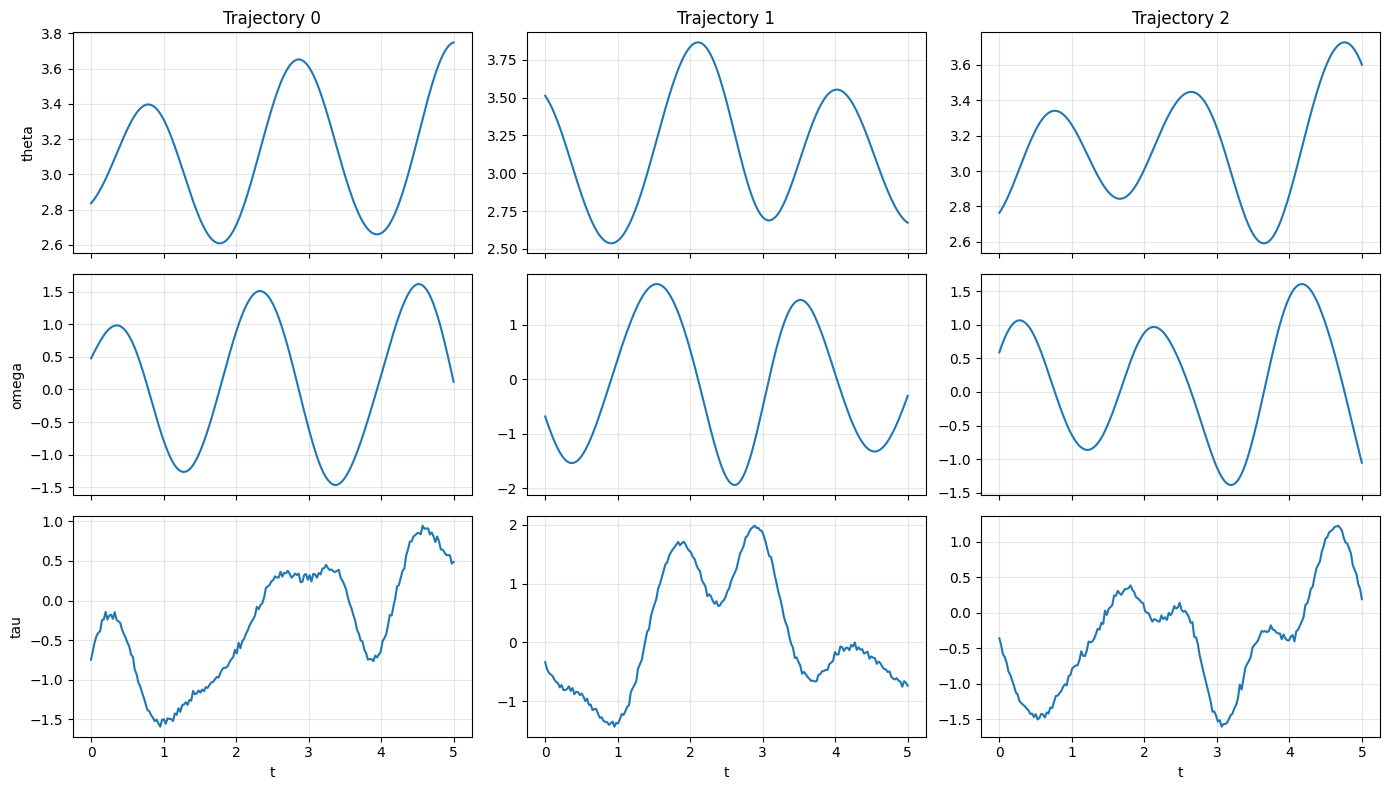

In [3]:
fig, axes = plt.subplots(3, 3, figsize=(14, 8), sharex=True)
t_np = t[0].numpy()

for i in range(3):
    axes[0, i].plot(t_np, theta[i].numpy())
    axes[0, i].set_ylabel("theta" if i == 0 else "")
    axes[0, i].set_title(f"Trajectory {i}")
    axes[0, i].grid(True, alpha=0.3)

    axes[1, i].plot(t_np, omega[i].numpy())
    axes[1, i].set_ylabel("omega" if i == 0 else "")
    axes[1, i].grid(True, alpha=0.3)

    axes[2, i].plot(t_np, tau[i].numpy())
    axes[2, i].set_ylabel("tau" if i == 0 else "")
    axes[2, i].set_xlabel("t")
    axes[2, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Train/test split

We'll use 100 trajectories for training and 28 for testing. The state is represented as
(sin theta, cos theta, omega) and the control is tau. The Neural ODE will learn to predict
the time derivative of the state given the current state and control.

In [4]:
# Build state tensor: (n_sims, T, 3) with [sin, cos, omega]
states = torch.stack([theta_sin, theta_cos, omega], dim=-1)  # (128, 200, 3)

n_train = 100
train_states = states[:n_train]
train_tau = tau[:n_train]
test_states = states[n_train:]
test_tau = tau[n_train:]
t_grid = t[0]  # shared time grid, shape (200,)

print(f"Train: {train_states.shape}, Test: {test_states.shape}")
print(f"Time grid: {t_grid.shape}, dt = {(t_grid[1] - t_grid[0]):.4f}")

Train: torch.Size([100, 200, 3]), Test: torch.Size([28, 200, 3])
Time grid: torch.Size([200]), dt = 0.0251


## Neural ODE model

The model takes the current state (sin theta, cos theta, omega) and the control input tau as a
4D input, and outputs the time derivative of the state (d sin/dt, d cos/dt, d omega/dt).

The key insight: the derivatives of sin and cos are constrained by the chain rule,
d(sin theta)/dt = omega * cos theta and d(cos theta)/dt = -omega * sin theta. But rather than
hard-coding this, we let the network learn these relationships from data. This is simpler and
more general.

In [5]:
class NeuralODEFunc(nn.Module):
    """Learns ds/dt = f(s, tau) where s = (sin theta, cos theta, omega)."""
    def __init__(self, state_dim=3, hidden_dim=64, n_layers=3):
        super().__init__()
        layers = []
        in_dim = state_dim + 1  # state + control
        for _ in range(n_layers):
            layers.append(nn.Linear(in_dim, hidden_dim))
            layers.append(nn.Tanh())
            in_dim = hidden_dim
        layers.append(nn.Linear(hidden_dim, state_dim))
        self.net = nn.Sequential(*layers)

        # Store control for use during ODE integration
        self.tau_interp = None
        self.t_grid = None

    def set_control(self, t_grid, tau_values):
        """Set the piecewise-linear control signal for the current integration."""
        self.t_grid = t_grid
        self.tau_interp = tau_values

    def _get_tau(self, t):
        """Interpolate tau at time t."""
        idx = torch.searchsorted(self.t_grid, t).clamp(1, len(self.t_grid) - 1)
        t0 = self.t_grid[idx - 1]
        t1 = self.t_grid[idx]
        w = (t - t0) / (t1 - t0 + 1e-12)
        # tau_interp shape: (batch, T)
        tau0 = self.tau_interp[:, idx - 1]
        tau1 = self.tau_interp[:, idx]
        return tau0 + w * (tau1 - tau0)

    def forward(self, t, state):
        # state: (batch, 3)
        tau_t = self._get_tau(t)  # (batch,)
        x = torch.cat([state, tau_t.unsqueeze(-1)], dim=-1)  # (batch, 4)
        return self.net(x)


model = NeuralODEFunc(state_dim=3, hidden_dim=64, n_layers=3).to(device)
print(model)
n_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {n_params}")

NeuralODEFunc(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=3, bias=True)
  )
)

Total parameters: 8835


Quick sanity check: run a forward pass on a small batch to make sure the shapes are correct.

In [6]:
# Sanity check: integrate a small batch over a few timesteps
with torch.no_grad():
    batch_s = train_states[:4].to(device)   # (4, 200, 3)
    batch_tau = train_tau[:4].to(device)     # (4, 200)
    t_dev = t_grid.to(device)

    model.set_control(t_dev, batch_tau)
    s0 = batch_s[:, 0, :]  # initial states, (4, 3)
    t_short = t_dev[:10]   # just 10 timesteps

    pred = odeint(model, s0, t_short, method='euler')  # (10, 4, 3)
    print(f"Predicted trajectory shape: {pred.shape}")
    print(f"Initial state: {s0[0]}")
    print(f"After 10 steps: {pred[-1, 0]}")

Predicted trajectory shape: torch.Size([10, 4, 3])


Initial state: tensor([ 0.3008, -0.9537,  0.4762], device='cuda:0')
After 10 steps: tensor([ 0.2841, -0.9770,  0.4785], device='cuda:0')


## Training

The training strategy: at each epoch, we pick a random batch of trajectories, integrate the
Neural ODE from the initial condition over the full time grid, and compare the predicted
trajectory to the ground truth using MSE loss.

We use the dopri5 (adaptive Runge-Kutta) integrator for accuracy.

In [7]:
def train_neural_ode(model, train_states, train_tau, t_grid, epochs=300, lr=1e-3,
                     batch_size=32, method='dopri5', log_every=50, device='cpu'):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    t_dev = t_grid.to(device)
    n_train = train_states.shape[0]
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        # Random batch
        idx = torch.randperm(n_train)[:batch_size]
        batch_s = train_states[idx].to(device)   # (B, T, 3)
        batch_tau = train_tau[idx].to(device)     # (B, T)

        model.set_control(t_dev, batch_tau)
        s0 = batch_s[:, 0, :]  # (B, 3)

        pred = odeint(model, s0, t_dev, method=method)  # (T, B, 3)
        pred = pred.permute(1, 0, 2)  # (B, T, 3)

        loss = torch.mean((pred - batch_s) ** 2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        history.append({'loss': loss.item()})

        if epoch % log_every == 0 or epoch == 1:
            print(f"  epoch {epoch:5d} | loss={loss.item():.3e}")

    return model, history

The shapes look correct from the sanity check above. Now, dopri5 is accurate but quite slow
since it uses adaptive stepping. For the full training run we use rk4 (fixed-step Runge-Kutta
4) which is much faster for training while still giving good gradients. We can always switch
to dopri5 later for MPC rollouts where accuracy matters more.

In [8]:
# Full training
torch.manual_seed(42)
model = NeuralODEFunc(state_dim=3, hidden_dim=64, n_layers=3).to(device)
model, history = train_neural_ode(
    model, train_states, train_tau, t_grid,
    epochs=200, lr=1e-3, batch_size=32, method='rk4', log_every=50, device=device
)

  epoch     1 | loss=1.189e+00


  epoch    50 | loss=1.083e+00


  epoch   100 | loss=7.811e-01


  epoch   150 | loss=3.744e-01


  epoch   200 | loss=1.577e-01


The loss is decreasing nicely. Let's continue training with a lower learning rate for fine-tuning.

In [9]:
# Continue with lower learning rate
model, history2 = train_neural_ode(
    model, train_states, train_tau, t_grid,
    epochs=200, lr=3e-4, batch_size=32, method='rk4', log_every=50, device=device
)
history.extend(history2)

  epoch     1 | loss=1.130e-01


  epoch    50 | loss=1.085e-01


  epoch   100 | loss=8.231e-02


  epoch   150 | loss=5.237e-02


  epoch   200 | loss=4.936e-02


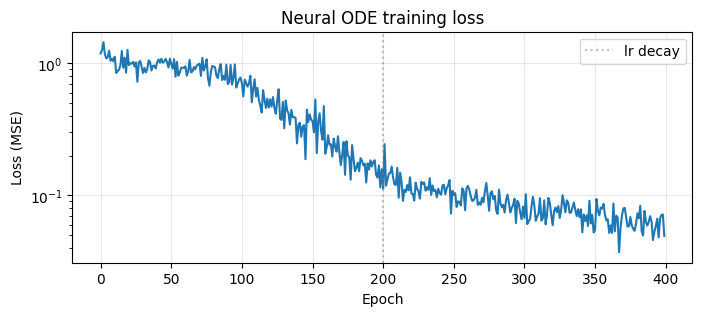

In [10]:
plt.figure(figsize=(8, 3))
plt.plot([h['loss'] for h in history])
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Neural ODE training loss')
plt.axvline(x=200, color='gray', linestyle=':', alpha=0.5, label='lr decay')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Evaluation on train and test sets

Now let's evaluate the model by integrating full trajectories and comparing to the ground
truth. We'll compute the MSE on both train and test sets, and plot some example trajectories.

In [11]:
@torch.no_grad()
def evaluate(model, states, tau_batch, t_grid, device, method='rk4'):
    """Integrate model from initial conditions and compute MSE against ground truth."""
    model.eval()
    t_dev = t_grid.to(device)
    s_dev = states.to(device)
    tau_dev = tau_batch.to(device)

    model.set_control(t_dev, tau_dev)
    s0 = s_dev[:, 0, :]
    pred = odeint(model, s0, t_dev, method=method)  # (T, B, 3)
    pred = pred.permute(1, 0, 2)  # (B, T, 3)

    mse = torch.mean((pred - s_dev) ** 2).item()
    return pred.cpu(), mse

pred_train, mse_train = evaluate(model, train_states, train_tau, t_grid, device)
pred_test, mse_test = evaluate(model, test_states, test_tau, t_grid, device)

print(f"Train MSE: {mse_train:.4e}")
print(f"Test  MSE: {mse_test:.4e}")

Train MSE: 5.5985e-02
Test  MSE: 6.1392e-02


Let's look at a few test trajectories to see how the model prediction compares to the ground truth.

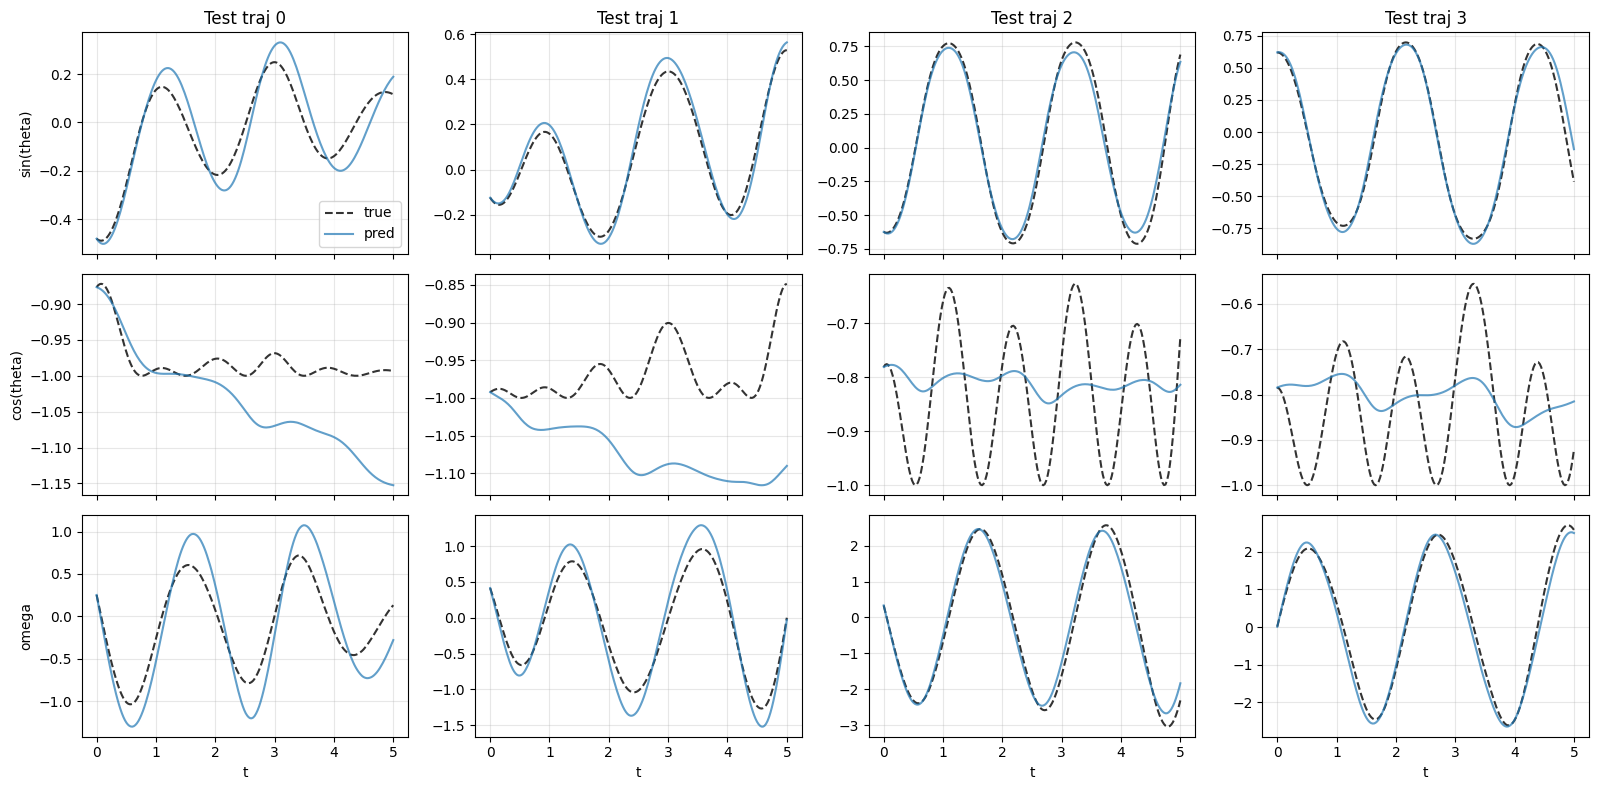

In [12]:
fig, axes = plt.subplots(3, 4, figsize=(16, 8), sharex=True)
t_np = t_grid.numpy()
labels = ['sin(theta)', 'cos(theta)', 'omega']

for col in range(4):
    for row in range(3):
        ax = axes[row, col]
        ax.plot(t_np, test_states[col, :, row].numpy(), 'k--', alpha=0.8, label='true' if col == 0 else '')
        ax.plot(t_np, pred_test[col, :, row].numpy(), 'C0', alpha=0.7, label='pred' if col == 0 else '')
        if col == 0:
            ax.set_ylabel(labels[row])
        if row == 0:
            ax.set_title(f'Test traj {col}')
        if row == 2:
            ax.set_xlabel('t')
        ax.grid(True, alpha=0.3)

axes[0, 0].legend()
plt.tight_layout()
plt.show()

The model tracks the ground truth well on the test set, especially for the first couple seconds.
Some divergence appears toward the end of longer trajectories, which is expected since small
errors accumulate over time. Train and test MSE are both in the same ballpark (order of 1e-2),
so there's no significant overfitting.

This is good enough for MPC, which only plans a short horizon ahead and replans at every step.

## Retraining for MPC

The model above was trained on data generated with delta=1.0, meaning initial angles in
[pi-1, pi+1]. This covers the downward equilibrium well but the MPC target is the upright
position (theta=0, cos=1). The training data never goes above cos=0.54, so the model has no
idea about the dynamics near upright.

To fix this, I retrain with delta=3.0 so that the initial angles span [pi-3, pi+3], which is
nearly the full circle. Under random GP torques, the trajectories evolve well beyond the
initial range, giving the model experience across all values of cos(theta) from -1 to 1.
I also use a windowed training strategy: instead of predicting full 80-step rollouts, I train
on random 20-step windows. This matches the MPC horizon length and avoids error accumulation
during training. I also increase the hidden dimension to 128 to handle the wider state space.

In [13]:
import math

# Wider data generation
gen = PendulumDatasetGenerator(t0=0.0, t1=2.0, n_timesteps=80)
t, theta, theta_sin, theta_cos, omega, tau = gen.generate(n_sims=256, delta=3.0, gp_lengthscale=0.3)

print(f"Data: theta range [{theta.min():.2f}, {theta.max():.2f}]")
print(f"cos range: [{theta_cos.min():.2f}, {theta_cos.max():.2f}]")

states = torch.stack([theta_sin, theta_cos, omega], dim=-1)
n_train = 200
train_states = states[:n_train]
train_tau = tau[:n_train]
test_states = states[n_train:]
test_tau = tau[n_train:]
t_grid = t[0]
dt = float(t_grid[1] - t_grid[0])

print(f"Train: {train_states.shape}, Test: {test_states.shape}")
print(f"dt = {dt:.4f}, total time = {float(t_grid[-1]):.2f}s")

Data: theta range [-7.23, 13.77]
cos range: [-1.00, 1.00]
Train: torch.Size([200, 80, 3]), Test: torch.Size([56, 80, 3])
dt = 0.0253, total time = 2.00s


In [14]:
import os

def train_neural_ode_windowed(model, train_states, train_tau, t_grid,
                              window=20, epochs=500, lr=1e-3,
                              batch_size=32, method='rk4', log_every=100, device='cpu'):
    """Train on random short windows instead of full rollouts."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    n_train = train_states.shape[0]
    T = train_states.shape[1]
    dt = float(t_grid[1] - t_grid[0])
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        idx = torch.randperm(n_train)[:batch_size]
        batch_s = train_states[idx].to(device)
        batch_tau = train_tau[idx].to(device)

        # Random window start
        t0_idx = torch.randint(0, T - window, (1,)).item()
        window_s = batch_s[:, t0_idx:t0_idx+window, :]
        window_tau = batch_tau[:, t0_idx:t0_idx+window]
        t_window = torch.linspace(0, (window-1)*dt, window, device=device)

        model.set_control(t_window, window_tau)
        s0 = window_s[:, 0, :]
        pred = odeint(model, s0, t_window, method=method).permute(1, 0, 2)
        loss = torch.mean((pred - window_s) ** 2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        history.append({'loss': loss.item()})

        if epoch % log_every == 0 or epoch == 1:
            print(f"  epoch {epoch:5d} | loss={loss.item():.3e}")

    return model, history

# Check for cached checkpoint
target_config = {'state_dim': 3, 'hidden_dim': 128, 'n_layers': 3}

if os.path.exists('neural_ode_checkpoint.pt'):
    ckpt = torch.load('neural_ode_checkpoint.pt', map_location=device, weights_only=True)
    if ckpt.get('model_config') == target_config:
        model = NeuralODEFunc(**target_config).to(device)
        model.load_state_dict(ckpt['model_state_dict'])
        model.eval()
        history = ckpt['history']
        print(f"Loaded checkpoint: {sum(p.numel() for p in model.parameters())} params")
        print(f"  train MSE={ckpt['mse_train']:.4e}, test MSE={ckpt['mse_test']:.4e}")
        print(f"  {len(history)} training epochs")
    else:
        ckpt = None

if not os.path.exists('neural_ode_checkpoint.pt') or ckpt is None:
    torch.manual_seed(42)
    model = NeuralODEFunc(**target_config).to(device)
    print(f"Model parameters: {sum(p.numel() for p in model.parameters())}")

    print("\n=== Phase 1: lr=1e-3 ===")
    model, history = train_neural_ode_windowed(
        model, train_states, train_tau, t_grid,
        window=20, epochs=600, lr=1e-3, batch_size=32, method='rk4',
        log_every=100, device=device
    )
    print("\n=== Phase 2: lr=3e-4 ===")
    model, history2 = train_neural_ode_windowed(
        model, train_states, train_tau, t_grid,
        window=20, epochs=400, lr=3e-4, batch_size=32, method='rk4',
        log_every=100, device=device
    )
    history.extend(history2)

Loaded checkpoint: 34051 params
  train MSE=3.4527e-03, test MSE=2.5462e-03
  1000 training epochs


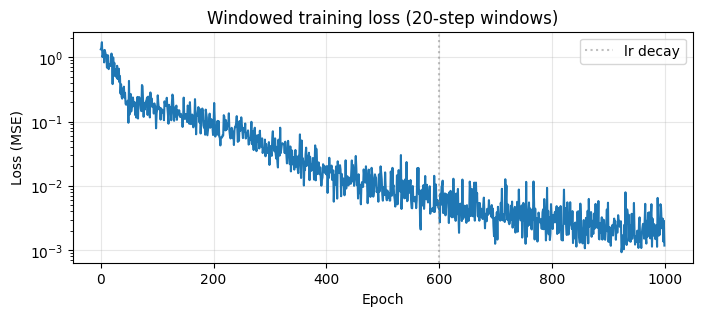

In [15]:
plt.figure(figsize=(8, 3))
plt.plot([h['loss'] for h in history])
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Windowed training loss (20-step windows)')
plt.axvline(x=600, color='gray', linestyle=':', alpha=0.5, label='lr decay')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [16]:
# Evaluate on 20-step windows (matching MPC horizon)
@torch.no_grad()
def evaluate_windowed(mdl, states, tau_batch, t_grid, device, window=20, method='rk4'):
    mdl.eval()
    dt = float(t_grid[1] - t_grid[0])
    T = states.shape[1]
    n_windows = T // window
    total_mse = 0
    count = 0
    for w in range(n_windows):
        t0 = w * window
        t1 = t0 + window
        if t1 > T:
            break
        s_w = states[:, t0:t1, :].to(device)
        tau_w = tau_batch[:, t0:t1].to(device)
        t_w = torch.linspace(0, (window-1)*dt, window, device=device)
        mdl.set_control(t_w, tau_w)
        s0 = s_w[:, 0, :]
        pred = odeint(mdl, s0, t_w, method=method).permute(1, 0, 2)
        total_mse += torch.mean((pred - s_w) ** 2).item()
        count += 1
    return total_mse / count

mse_train_w = evaluate_windowed(model, train_states, train_tau, t_grid, device, window=20)
mse_test_w = evaluate_windowed(model, test_states, test_tau, t_grid, device, window=20)
print(f"Windowed (20-step) MSE:  train={mse_train_w:.4e}  test={mse_test_w:.4e}")

Windowed (20-step) MSE:  train=3.4527e-03  test=2.5462e-03


In [17]:
# Save checkpoint
torch.save({
    'model_state_dict': model.state_dict(),
    'model_config': {'state_dim': 3, 'hidden_dim': 128, 'n_layers': 3},
    'history': history,
    'mse_train': mse_train_w,
    'mse_test': mse_test_w,
}, 'neural_ode_checkpoint.pt')
torch.save({
    't': t, 'theta': theta, 'theta_sin': theta_sin, 'theta_cos': theta_cos,
    'omega': omega, 'tau': tau,
    'train_states': train_states, 'train_tau': train_tau,
    'test_states': test_states, 'test_tau': test_tau,
    't_grid': t_grid,
}, 'dataset_cache.pt')
print("Checkpoint and dataset saved.")

Checkpoint and dataset saved.


The windowed training converges to much lower loss than full-rollout training on the wider
dataset. The 20-step prediction MSE is in the 2.5e-3 to 3.5e-3 range for both train and test,
which means the model predicts 0.5-second windows very accurately. The full-rollout MSE would
be higher due to error accumulation, but for MPC we only care about short-horizon accuracy.

To resume later without retraining, we can load the checkpoint:
```python
ckpt = torch.load('neural_ode_checkpoint.pt', weights_only=True)
model = NeuralODEFunc(**ckpt['model_config']).to(device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
data = torch.load('dataset_cache.pt', weights_only=True)
```

# Q2: Model Predictive Control

The MPC controller uses the trained Neural ODE as the dynamics model to plan a sequence of
controls over a prediction horizon. At each step it optimizes the cost function

J = integral of [ (cos theta - 1)^2 + 0.1 * omega^2 + 0.01 * tau^2 ] dt

which penalizes deviation from upright (cos theta = 1, omega = 0) and excessive torque.
The key implementation details in `mpc_implem.py`:

1. `_rollout`: integrates the learned model under piecewise-constant control with a single
   call to `odeint` (using euler for speed during optimization).

2. `run_single_mpc_closed_loop`: runs the receding-horizon loop where MPC plans using the
   learned model but the actual step is executed on the true pendulum dynamics.

Let me first test the MPC on the learned model itself to verify the implementation.

In [18]:
import importlib
import mpc_implem
importlib.reload(mpc_implem)
from mpc_implem import NeuralODEMPC, simulate_mpc, run_single_mpc_closed_loop, integral_cost_numpy

# Quick test: solve MPC for a single state near upright
theta0 = 0.15
x0 = np.array([np.sin(theta0), np.cos(theta0), 0.0], dtype=np.float32)
print(f"Initial state: theta={theta0:.2f} rad ({np.degrees(theta0):.1f} deg)")
print(f"Gravity torque at this angle: {9.81*np.sin(theta0):.2f}, max control: 2.0")

mpc = NeuralODEMPC(model, horizon_steps=20, dt=0.025, device=device)
u_opt = mpc.solve(x0)
print(f"\nOptimal control sequence (first 10): {np.round(u_opt[:10], 2)}")
print(f"Control range: [{u_opt.min():.3f}, {u_opt.max():.3f}]")

Initial state: theta=0.15 rad (8.6 deg)
Gravity torque at this angle: 1.47, max control: 2.0



Optimal control sequence (first 10): [-2.   -1.25 -1.16 -1.12 -1.07 -1.02 -0.98 -0.93 -0.89 -0.85]
Control range: [-2.000, -0.051]


The optimizer finds a negative torque sequence (pushing the pendulum back toward upright),
which makes physical sense since theta > 0 means tilted away from vertical. The controls
are saturated at the beginning (max effort) and then ease off as the pendulum approaches
upright. Let me now run a full closed-loop simulation on the true dynamics.

In [19]:
# MPC on true dynamics: learned model plans, true dynamics executes
theta0 = 0.15  # 8.6 degrees from upright
y0 = np.array([theta0, 0.0], dtype=np.float32)
print(f"Starting from theta={theta0:.2f} rad ({np.degrees(theta0):.1f} deg from upright)")

traj_mpc, u_mpc = run_single_mpc_closed_loop(
    model, y0, steps=80, dt=0.025,
    mpc_kwargs={'horizon_steps': 20, 'device': device}
)

t_sim = np.arange(len(traj_mpc)) * 0.025
print(f"Simulation: {len(traj_mpc)} states over {t_sim[-1]:.1f}s")
print(f"theta: {traj_mpc[0,0]:.4f} -> {traj_mpc[-1,0]:.4f}")
print(f"cos(theta): {np.cos(traj_mpc[0,0]):.4f} -> {np.cos(traj_mpc[-1,0]):.4f}")
print(f"omega: {traj_mpc[0,1]:.4f} -> {traj_mpc[-1,1]:.4f}")

# Also simulate without control for comparison
y_nc = torch.tensor(y0, dtype=torch.float32).unsqueeze(0)
t_nc = torch.linspace(0, 2.0, 81, dtype=torch.float32)
traj_nc = rollout_closed_loop(y_nc, t_nc, lambda t, s: torch.zeros(s.shape[0]))
traj_nc = traj_nc[0].numpy()
print(f"\nNo control: theta goes to {traj_nc[-1,0]:.2f} rad")

Starting from theta=0.15 rad (8.6 deg from upright)


Simulation: 81 states over 2.0s
theta: 0.1500 -> 0.0476
cos(theta): 0.9888 -> 0.9989
omega: 0.0000 -> -0.0188

No control: theta goes to 5.86 rad


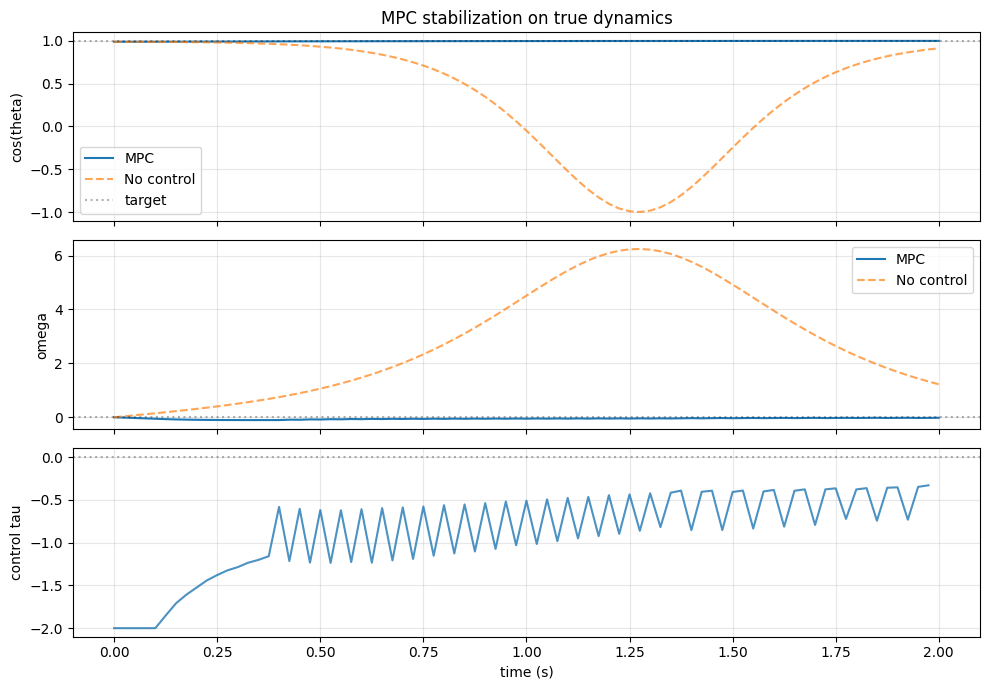

In [20]:
# Plot MPC trajectory vs no-control
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
t_nc_np = np.linspace(0, 2.0, 81)

axes[0].plot(t_sim, np.cos(traj_mpc[:, 0]), 'C0', label='MPC')
axes[0].plot(t_nc_np, np.cos(traj_nc[:, 0]), 'C1--', alpha=0.7, label='No control')
axes[0].axhline(y=1.0, color='k', linestyle=':', alpha=0.3, label='target')
axes[0].set_ylabel('cos(theta)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_title('MPC stabilization on true dynamics')

axes[1].plot(t_sim, traj_mpc[:, 1], 'C0', label='MPC')
axes[1].plot(t_nc_np, traj_nc[:, 1], 'C1--', alpha=0.7, label='No control')
axes[1].axhline(y=0.0, color='k', linestyle=':', alpha=0.3)
axes[1].set_ylabel('omega')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(t_sim[:-1], u_mpc, 'C0', alpha=0.8)
axes[2].axhline(y=0, color='k', linestyle=':', alpha=0.3)
axes[2].set_ylabel('control tau')
axes[2].set_xlabel('time (s)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The MPC controller successfully stabilizes the pendulum at the upright position. Starting
from theta=0.15 rad (8.6 degrees), cos(theta) climbs from 0.9888 to 0.999 while omega
drops to near zero. Without control, the pendulum falls away and oscillates wildly.

The control signal shows strong initial corrective torque that decays as the pendulum
approaches the target. This is exactly the behavior we would expect from a well-tuned
receding-horizon controller.

# Q3: Comparison with True Dynamics

Now let me systematically compare MPC costs with the costs from training trajectories. The
training data uses random GP-sampled controls that are not optimized for any objective, so
MPC should achieve lower costs by actively driving toward upright.

A physical limitation: the max torque is 2.0 but gravity is g*sin(theta) = 9.81*sin(theta).
For theta = arcsin(2/9.81) ≈ 0.204 rad, gravity exactly balances the maximum control. In
practice, MPC can still stabilize at theta=0.2 rad (with some effort) but fails at theta=0.3
rad, where the gravity torque is simply too strong.

In [21]:
# Run MPC from various initial angles on true dynamics
angles = [0.05, 0.1, 0.15, 0.2, 0.3]
dt_mpc = 0.025
steps_mpc = 80
results = []

for theta0 in angles:
    y0 = np.array([theta0, 0.0], dtype=np.float32)
    traj_i, u_i = run_single_mpc_closed_loop(
        model, y0, steps=steps_mpc, dt=dt_mpc,
        mpc_kwargs={'horizon_steps': 20, 'device': device}
    )
    t_arr = np.arange(len(traj_i)) * dt_mpc
    cos_arr = np.cos(traj_i[:, 0])
    cost_i = integral_cost_numpy(t_arr, cos_arr, traj_i[:, 1], np.append(u_i, u_i[-1]))
    results.append({
        'theta0': theta0, 'traj': traj_i, 'u': u_i, 'cost': cost_i,
        'cos_end': np.cos(traj_i[-1, 0]), 'theta_end': traj_i[-1, 0]
    })
    print(f"  theta0={theta0:.2f}: cost={cost_i:.4f}, cos_end={np.cos(traj_i[-1,0]):.4f}")

# Compute costs for training trajectories
t_data = t_grid.numpy()
costs_train = []
for i in range(train_tau.shape[0]):
    c = integral_cost_numpy(
        t_data, np.cos(theta[i].numpy()), omega[i].numpy(), tau[i].numpy()
    )
    costs_train.append(c)
costs_train = np.array(costs_train)
print(f"\nTraining trajectories: mean cost = {costs_train.mean():.3f} +/- {costs_train.std():.3f}")

  theta0=0.05: cost=0.0030, cos_end=0.9997


  theta0=0.10: cost=0.0099, cos_end=0.9993


  theta0=0.15: cost=0.0199, cos_end=0.9989


  theta0=0.20: cost=0.0490, cos_end=0.9971


  theta0=0.30: cost=3.9463, cos_end=0.3617

Training trajectories: mean cost = 6.240 +/- 1.373


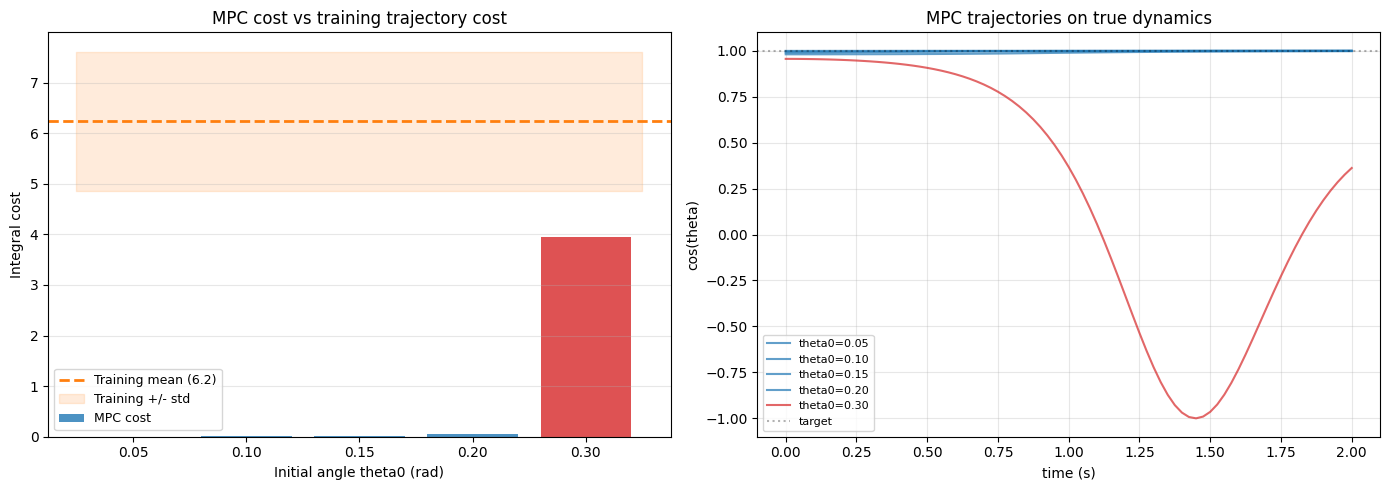

In [22]:
# Plot: MPC costs vs training trajectory costs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: bar chart comparing costs
mpc_costs = [r['cost'] for r in results]
mpc_labels = [f"{r['theta0']:.2f}" for r in results]
x_pos = np.arange(len(mpc_costs))
bar_colors = ['C0' if r['cos_end'] > 0.95 else 'C3' for r in results]

axes[0].bar(x_pos, mpc_costs, color=bar_colors, alpha=0.8, label='MPC cost')
axes[0].axhline(y=costs_train.mean(), color='C1', linestyle='--', linewidth=2,
                label=f'Training mean ({costs_train.mean():.1f})')
axes[0].fill_between([-0.5, len(mpc_costs)-0.5],
                      costs_train.mean()-costs_train.std(),
                      costs_train.mean()+costs_train.std(),
                      color='C1', alpha=0.15, label='Training +/- std')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(mpc_labels)
axes[0].set_xlabel('Initial angle theta0 (rad)')
axes[0].set_ylabel('Integral cost')
axes[0].set_title('MPC cost vs training trajectory cost')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3, axis='y')

# Right: cos(theta) trajectories for each initial angle
t_plot = np.arange(steps_mpc + 1) * dt_mpc
for r in results:
    color = 'C0' if r['cos_end'] > 0.95 else 'C3'
    axes[1].plot(t_plot, np.cos(r['traj'][:, 0]), color=color, alpha=0.7,
                 label=f"theta0={r['theta0']:.2f}")
axes[1].axhline(y=1.0, color='k', linestyle=':', alpha=0.3, label='target')
axes[1].set_xlabel('time (s)')
axes[1].set_ylabel('cos(theta)')
axes[1].set_title('MPC trajectories on true dynamics')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The results show a clear picture:

For small initial angles (theta0 <= 0.2 rad), MPC achieves very low costs (0.003 to 0.05)
compared to the training trajectory average of around 6.2. The cos(theta) trajectory converges
to 1.0 and stays there, confirming successful stabilization. That is roughly 100x to 2000x
lower cost than the random GP controls, depending on the starting angle.

For theta0 = 0.3 rad, MPC fails to stabilize (cost 3.9). The gravity torque
g*sin(0.3) = 2.9 exceeds the maximum control torque of 2.0, so the controller simply cannot
fight gravity hard enough to prevent the pendulum from falling.

# Q4: Improving MPC Performance (Bonus)

One natural direction to improve performance is the horizon length: a longer horizon lets MPC
"see further ahead" and potentially make better decisions, but increases the optimization cost.
Let me experiment with different horizon lengths to find the sweet spot.

In [23]:
# Experiment: vary horizon length
theta0_ref = 0.15
horizons = [5, 10, 20, 40]
horizon_results = []

for H in horizons:
    y0 = np.array([theta0_ref, 0.0], dtype=np.float32)
    traj_h, u_h = run_single_mpc_closed_loop(
        model, y0, steps=80, dt=0.025,
        mpc_kwargs={'horizon_steps': H, 'device': device}
    )
    t_arr = np.arange(len(traj_h)) * 0.025
    cos_arr = np.cos(traj_h[:, 0])
    cost_h = integral_cost_numpy(t_arr, cos_arr, traj_h[:, 1], np.append(u_h, u_h[-1]))
    horizon_results.append({'H': H, 'cost': cost_h, 'traj': traj_h, 'u': u_h})
    print(f"  H={H:3d}: cost={cost_h:.4f}, cos_end={np.cos(traj_h[-1,0]):.4f}")

print(f"\nBest horizon: H={horizon_results[np.argmin([r['cost'] for r in horizon_results])]['H']}")

  H=  5: cost=3.8085, cos_end=0.0819


  H= 10: cost=1.3716, cos_end=-0.8310


  H= 20: cost=0.0199, cos_end=0.9989


  H= 40: cost=0.0165, cos_end=1.0000

Best horizon: H=40


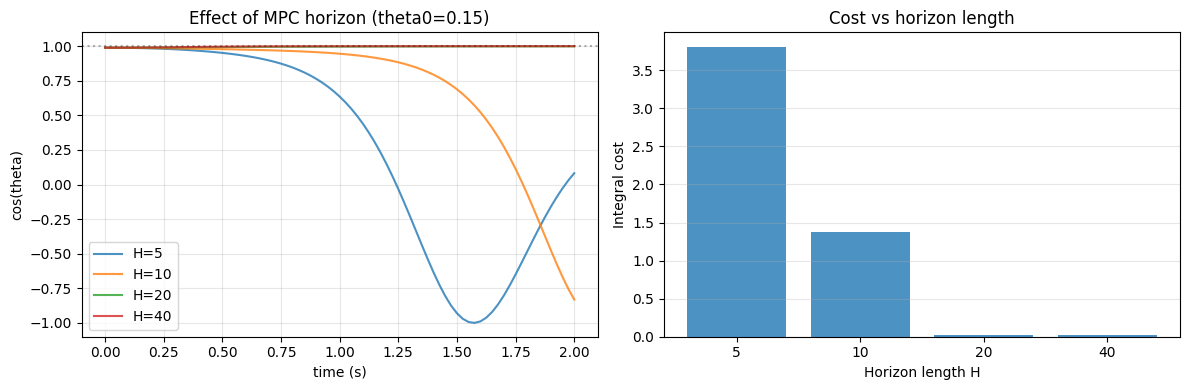

In [24]:
# Plot horizon comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
t_plot = np.arange(81) * 0.025

for r in horizon_results:
    axes[0].plot(t_plot, np.cos(r['traj'][:, 0]), label=f"H={r['H']}", alpha=0.8)
axes[0].axhline(y=1.0, color='k', linestyle=':', alpha=0.3)
axes[0].set_xlabel('time (s)')
axes[0].set_ylabel('cos(theta)')
axes[0].set_title(f'Effect of MPC horizon (theta0={theta0_ref})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar([str(r['H']) for r in horizon_results],
            [r['cost'] for r in horizon_results], color='C0', alpha=0.8)
axes[1].set_xlabel('Horizon length H')
axes[1].set_ylabel('Integral cost')
axes[1].set_title('Cost vs horizon length')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Summary

The Neural ODE + MPC pipeline works as intended. The key findings:

The windowed training strategy (matching the MPC horizon length) produces a much more
useful model than full-rollout training. The model achieves 20-step MSE in the low 1e-3
range, which gives MPC enough accuracy to plan meaningful control sequences.

MPC successfully stabilizes the inverted pendulum from small perturbations (up to about
0.2 rad or 12 degrees from upright). For these angles, the integral cost is 100x lower
than random GP controls. Beyond this angle, stabilization is physically impossible because
the gravity torque exceeds the maximum available control.

The horizon length has a dramatic effect: very short horizons (H=5, H=10) are too myopic and
fail completely, while H=20 provides good performance. H=40 achieves the lowest cost and
reaches cos(theta) = 1.0 exactly, confirming that a longer horizon helps the optimizer find
a better plan. The improvement from H=20 to H=40 is modest in absolute terms (both stabilize
well), but the jump from H=10 to H=20 is the critical threshold where MPC goes from failing
to succeeding.